# 📐 구현 과제 1 — NumPy 선형대수 기초

**목표:** 행렬 곱셈 · 브로드캐스팅 · 코사인 유사도를 직접 구현하고, 성능 실험 결과를 wandb에 기록한다.

**포트폴리오 위치:** `portfolio-tsuruoka-lab/phase0-math-python/01-numpy-linear-algebra/`

---

## 학습 목표
- [ ] 행렬 곱셈을 3가지 방법으로 구현하고 속도 차이를 체감한다
- [ ] 브로드캐스팅 규칙을 코드로 직접 검증한다
- [ ] 코사인 유사도를 수식 → numpy 행렬 연산으로 구현한다
- [ ] 실험 결과를 wandb에 기록하는 워크플로를 익힌다

## AI 연결
오늘 구현한 것들이 나중에 이렇게 쓰입니다:
- **행렬 곱셈** → Transformer의 모든 선형 변환 (`Q @ K.T`)
- **브로드캐스팅** → Attention mask, Layer Norm, 편향 더하기
- **코사인 유사도** → 단어 임베딩 유사도, Retrieval 시스템

## 0. 환경 설정

In [1]:
# ── 패키지 설치 (Colab 최초 1회) ──────────────────────────────────────────
!pip install wandb -q

In [2]:
import numpy as np
import time
import wandb
from IPython.display import display
import matplotlib.pyplot as plt

# 재현성을 위한 시드 고정
np.random.seed(42)

print("NumPy version:", np.__version__)
print("환경 설정 완료 ✓")

NumPy version: 2.0.2
환경 설정 완료 ✓


In [3]:
# ── wandb 로그인 ──────────────────────────────────────────────────────────
# Colab Secrets에 WANDB_API_KEY를 등록했다면 아래 방법 사용:
# from google.colab import userdata
# import os
# os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')

# 처음이라면 아래 한 줄로 브라우저 로그인:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 13.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: swsw778 (swsw778-korea-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# ── wandb 실험 시작 ───────────────────────────────────────────────────────
run = wandb.init(
    project="portfolio-tsuruoka-lab",       # 프로젝트명 (wandb에서 폴더처럼 보임)
    name="phase0-01-linear-algebra",         # 이 실험의 이름
    tags=["phase0", "numpy", "linear-algebra"],
    config={
        "phase": 0,
        "assignment": 1,
        "topic": "matrix-multiplication-broadcasting",
    }
)
print(f"wandb run 시작: {run.url}")

wandb run 시작: https://wandb.ai/swsw778-korea-university/portfolio-tsuruoka-lab/runs/p6ok38yo


---
## 1. 행렬 곱셈 — 3가지 방법 구현 및 속도 비교

### 수식
$$C_{ij} = \sum_{k} A_{ik} \cdot B_{kj}$$

- $C_{ij}$는 A의 **i번째 행**과 B의 **j번째 열**의 **내적**
- A가 $(m \times k)$, B가 $(k \times n)$ 이면 → C는 $(m \times n)$

In [5]:
# ── 방법 1: for loop (원리 이해용) ────────────────────────────────────────
def matmul_loop(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """
    행렬 곱셈을 for loop으로 구현.
    가장 느리지만, C[i][j] = A의 i행 · B의 j열 임을 가장 명확하게 보여줌.
    """
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"Shape 불일치: A의 열({k}) ≠ B의 행({k2})"

    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for p in range(k):
                C[i, j] += A[i, p] * B[p, j]   # 핵심: 내적 한 칸씩
    return C


# 작은 행렬로 정확성 검증
A_small = np.array([[1, 2, 3],
                    [4, 5, 6]], dtype=float)     # (2, 3)
B_small = np.array([[7,  8],
                    [9,  10],
                    [11, 12]], dtype=float)       # (3, 2)

C_loop = matmul_loop(A_small, B_small)
print("[for loop 결과]")
print(C_loop)
# 기대값: [[58, 64], [139, 154]]

[for loop 결과]
[[ 58.  64.]
 [139. 154.]]


In [6]:
# ── 방법 2: np.dot / @ 연산자 (실전에서 사용) ─────────────────────────────
C_dot    = np.dot(A_small, B_small)   # 고전적 표기
C_matmul = A_small @ B_small          # 논문 코드에서 가장 흔한 표기

print("[@ 연산자 결과]")
print(C_matmul)

# 세 방법이 동일한지 확인
assert np.allclose(C_loop, C_dot), "loop과 dot 결과 불일치!"
assert np.allclose(C_dot, C_matmul), "dot과 @ 결과 불일치!"
print("\n세 방법 결과 일치 ✓")

[@ 연산자 결과]
[[ 58.  64.]
 [139. 154.]]

세 방법 결과 일치 ✓


In [7]:
# ── 방법 3: einsum (Transformer 코드에서 자주 등장) ───────────────────────
# 읽는 법: 'ik,kj->ij'
#   - A의 인덱스: i(행), k(열)
#   - B의 인덱스: k(행), j(열)
#   - 출력 인덱스: i, j  →  k가 없으므로 k방향으로 합산 = 내적

C_einsum = np.einsum('ik,kj->ij', A_small, B_small)
print("[einsum 결과]")
print(C_einsum)

# Transformer에서 실제로 보이는 einsum 패턴 예시
print("\n--- Transformer einsum 예시 (shape만 확인) ---")
Q = np.random.randn(2, 4, 10, 64)    # (batch, heads, seq, d_k)
K = np.random.randn(2, 4, 10, 64)

# Attention score: Q와 K의 내적
scores = np.einsum('bhqd,bhkd->bhqk', Q, K)
print(f"Q: {Q.shape}, K: {K.shape}")
print(f"Attention scores: {scores.shape}")   # (2, 4, 10, 10)

[einsum 결과]
[[ 58.  64.]
 [139. 154.]]

--- Transformer einsum 예시 (shape만 확인) ---
Q: (2, 4, 10, 64), K: (2, 4, 10, 64)
Attention scores: (2, 4, 10, 10)


In [8]:
# ── 속도 비교 실험 → wandb에 기록 ─────────────────────────────────────────
sizes = [16, 32, 64, 128, 256]
results = {"size": [], "loop_ms": [], "numpy_ms": [], "speedup": []}

for n in sizes:
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)

    # for loop 시간 측정 (작은 크기만)
    if n <= 64:
        t0 = time.perf_counter()
        matmul_loop(A, B)
        loop_ms = (time.perf_counter() - t0) * 1000
    else:
        loop_ms = None   # 너무 느려서 생략

    # numpy @ 시간 측정
    t0 = time.perf_counter()
    for _ in range(10):          # 10회 평균으로 노이즈 줄이기
        _ = A @ B
    numpy_ms = (time.perf_counter() - t0) / 10 * 1000

    speedup = (loop_ms / numpy_ms) if loop_ms else None

    results["size"].append(n)
    results["loop_ms"].append(loop_ms)
    results["numpy_ms"].append(numpy_ms)
    results["speedup"].append(speedup)

    # wandb에 한 스텝씩 기록
    log_dict = {
        "matmul/matrix_size": n,
        "matmul/numpy_ms": numpy_ms,
    }
    if loop_ms:
        log_dict["matmul/loop_ms"] = loop_ms
        log_dict["matmul/speedup_x"] = speedup

    wandb.log(log_dict)
    print(f"  n={n:4d} | numpy: {numpy_ms:.3f}ms"
          + (f" | loop: {loop_ms:.1f}ms | 속도차: {speedup:.0f}x" if loop_ms else " | loop: 생략(너무 느림)"))

print("\nwandb 기록 완료 ✓")

  n=  16 | numpy: 0.008ms | loop: 4.9ms | 속도차: 594x
  n=  32 | numpy: 0.019ms | loop: 44.3ms | 속도차: 2347x
  n=  64 | numpy: 0.675ms | loop: 339.2ms | 속도차: 503x
  n= 128 | numpy: 0.652ms | loop: 생략(너무 느림)
  n= 256 | numpy: 3.096ms | loop: 생략(너무 느림)

wandb 기록 완료 ✓


---
## 2. 브로드캐스팅 — 규칙 직접 검증

### 규칙 (오른쪽부터 비교)
각 차원이 ① 같거나 ② 둘 중 하나가 **1** 이면 브로드캐스팅 가능.  
차원 수가 부족하면 **앞에 1을 채워서** 비교한다.

In [9]:
# ── 케이스별 브로드캐스팅 검증 ────────────────────────────────────────────
print("=" * 55)
print("케이스 1: (2,3) + (3,) — 행 방향 복사")
print("=" * 55)
a = np.array([[1, 2, 3],
              [4, 5, 6]])          # (2, 3)
b = np.array([10, 20, 30])         # (3,) → (1,3) → (2,3)
result = a + b
print(f"a.shape: {a.shape}, b.shape: {b.shape}")
print(f"결과:\n{result}")
# [[11,22,33], [14,25,36]] — b가 각 행에 더해짐

print()
print("=" * 55)
print("케이스 2: (2,3) + (2,1) — 열 방향 복사 (편향처럼)")
print("=" * 55)
c = np.array([[100],
              [200]])              # (2, 1) → (2, 3)
result2 = a + c
print(f"a.shape: {a.shape}, c.shape: {c.shape}")
print(f"결과:\n{result2}")
# [[101,102,103], [204,205,206]] — 각 행에 다른 값이 더해짐

케이스 1: (2,3) + (3,) — 행 방향 복사
a.shape: (2, 3), b.shape: (3,)
결과:
[[11 22 33]
 [14 25 36]]

케이스 2: (2,3) + (2,1) — 열 방향 복사 (편향처럼)
a.shape: (2, 3), c.shape: (2, 1)
결과:
[[101 102 103]
 [204 205 206]]


In [10]:
print("=" * 55)
print("케이스 3: 신경망 y = x @ W + b 전체 흐름")
print("=" * 55)

batch_size   = 32
in_features  = 128
out_features = 64

x = np.random.randn(batch_size, in_features)    # (32, 128)
W = np.random.randn(in_features, out_features)  # (128, 64)
b = np.random.randn(out_features)               # (64,)

# ① 행렬 곱셈
xW = x @ W
print(f"x @ W → {x.shape} @ {W.shape} = {xW.shape}")

# ② 편향 더하기 (브로드캐스팅)
# b: (64,) → (1,64) → (32,64) 으로 자동 확장
y = xW + b
print(f"xW + b → {xW.shape} + {b.shape} = {y.shape}")
print(f"\n이 두 줄이 신경망 Dense 레이어 하나입니다.")

케이스 3: 신경망 y = x @ W + b 전체 흐름
x @ W → (32, 128) @ (128, 64) = (32, 64)
xW + b → (32, 64) + (64,) = (32, 64)

이 두 줄이 신경망 Dense 레이어 하나입니다.


In [11]:
print("=" * 55)
print("케이스 4: Transformer Attention 마스크")
print("=" * 55)

# Attention score: (batch, heads, seq, seq)
scores = np.random.randn(2, 4, 10, 10)

# 마스크: (seq, seq) — 한 번만 정의해서 모든 배치·헤드에 적용
# 상삼각 마스크: 미래 토큰을 못 보게 막는 것 (GPT 계열)
mask = np.triu(np.ones((10, 10)), k=1) * (-1e9)

# 브로드캐스팅: (10,10) → (1,1,10,10) → (2,4,10,10)
masked_scores = scores + mask
print(f"scores.shape: {scores.shape}")
print(f"mask.shape:   {mask.shape}")
print(f"결과.shape:   {masked_scores.shape}")
print("\n마스크 일부 확인 (대각선 위가 -1e9):")
print(mask[:4, :4])

# wandb에 브로드캐스팅 실험 결과 기록
wandb.log({
    "broadcasting/case1_row_expand": True,
    "broadcasting/case2_col_expand": True,
    "broadcasting/case3_bias_add":   True,
    "broadcasting/case4_attn_mask":  True,
})
print("\nwandb 기록 완료 ✓")

케이스 4: Transformer Attention 마스크
scores.shape: (2, 4, 10, 10)
mask.shape:   (10, 10)
결과.shape:   (2, 4, 10, 10)

마스크 일부 확인 (대각선 위가 -1e9):
[[-0.e+00 -1.e+09 -1.e+09 -1.e+09]
 [-0.e+00 -0.e+00 -1.e+09 -1.e+09]
 [-0.e+00 -0.e+00 -0.e+00 -1.e+09]
 [-0.e+00 -0.e+00 -0.e+00 -0.e+00]]

wandb 기록 완료 ✓


---
## 3. 코사인 유사도 — 수식 → 행렬 연산으로 구현

### 수식
$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

- 분자: 내적 (두 벡터가 얼마나 같은 방향인가)
- 분모: 각 벡터의 크기(norm)로 나눠서 정규화
- 범위: -1 (반대 방향) ~ 0 (직교) ~ 1 (완전히 같은 방향)
- 나중에 단어 임베딩의 유사도 계산에 그대로 사용됩니다

In [12]:
# ── 구현 1: 두 벡터 간 코사인 유사도 ─────────────────────────────────────
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    두 벡터 a, b의 코사인 유사도.
    cos(a,b) = (a · b) / (||a|| * ||b||)
    """
    dot   = np.dot(a, b)                         # 내적
    norm_a = np.linalg.norm(a)                   # ||a||
    norm_b = np.linalg.norm(b)                   # ||b||
    return dot / (norm_a * norm_b + 1e-8)        # 1e-8: 0 나누기 방지


# 직관 검증
v1 = np.array([1.0, 0.0])    # →  오른쪽
v2 = np.array([1.0, 0.0])    # →  오른쪽 (완전히 같음)
v3 = np.array([0.0, 1.0])    # ↑  위쪽 (직교)
v4 = np.array([-1.0, 0.0])   # ←  왼쪽 (반대)

print(f"같은 방향:  cos(v1, v2) = {cosine_similarity(v1, v2):.4f}  (기대: 1.0)")
print(f"직교:       cos(v1, v3) = {cosine_similarity(v1, v3):.4f}  (기대: 0.0)")
print(f"반대 방향:  cos(v1, v4) = {cosine_similarity(v1, v4):.4f}  (기대: -1.0)")

같은 방향:  cos(v1, v2) = 1.0000  (기대: 1.0)
직교:       cos(v1, v3) = 0.0000  (기대: 0.0)
반대 방향:  cos(v1, v4) = -1.0000  (기대: -1.0)


In [13]:
# ── 구현 2: 행렬 연산으로 N개 벡터 간 유사도 한 번에 계산 ─────────────────
# (나중에 word embedding 유사도 계산에서 그대로 재사용)
def cosine_similarity_matrix(X: np.ndarray) -> np.ndarray:
    """
    X: (N, D) — N개의 D차원 벡터
    반환: (N, N) 유사도 행렬

    핵심 아이디어:
    1. 각 벡터를 정규화 (unit vector로 만들기)
    2. 정규화된 행렬끼리 행렬 곱셈 = 모든 쌍의 코사인 유사도
    """
    # 각 벡터의 norm: (N,) → 브로드캐스팅을 위해 (N,1)로 reshape
    norms = np.linalg.norm(X, axis=1, keepdims=True)   # (N, 1)
    X_normalized = X / (norms + 1e-8)                  # (N, D) — 브로드캐스팅!

    # 행렬 곱셈으로 모든 쌍의 내적 한 번에 계산
    # X_norm @ X_norm.T : (N,D) @ (D,N) = (N,N)
    sim_matrix = X_normalized @ X_normalized.T
    return sim_matrix


# 가상의 단어 임베딩 (실제론 Word2Vec, GloVe 등에서 옴)
word_embeddings = np.array([
    [1.0, 0.2, 0.0],    # "왕"
    [0.9, 0.3, 0.1],    # "황제"  ← 왕과 비슷할 것
    [0.0, 1.0, 0.2],    # "물"
    [0.1, 0.8, 0.3],    # "강"    ← 물과 비슷할 것
    [0.0, 0.1, 1.0],    # "달리기"
])
words = ["왕", "황제", "물", "강", "달리기"]

sim = cosine_similarity_matrix(word_embeddings)

print("코사인 유사도 행렬:")
print(f"{'':8s}" + "".join(f"{w:8s}" for w in words))
for i, w in enumerate(words):
    row = "".join(f"{sim[i,j]:8.3f}" for j in range(len(words)))
    print(f"{w:8s}{row}")

print(f"\n'왕'-'황제' 유사도: {sim[0,1]:.3f}  (높을수록 유사)")
print(f"'물'-'강' 유사도:    {sim[2,3]:.3f}")
print(f"'왕'-'달리기' 유사도: {sim[0,4]:.3f}  (낮을수록 무관)")

코사인 유사도 행렬:
        왕       황제      물       강       달리기     
왕          1.000   0.987   0.192   0.296   0.020
황제         0.987   1.000   0.329   0.439   0.136
물          0.192   0.329   1.000   0.980   0.293
강          0.296   0.439   0.980   1.000   0.440
달리기        0.020   0.136   0.293   0.440   1.000

'왕'-'황제' 유사도: 0.987  (높을수록 유사)
'물'-'강' 유사도:    0.980
'왕'-'달리기' 유사도: 0.020  (낮을수록 무관)


/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7467/2112834640.py:20: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight

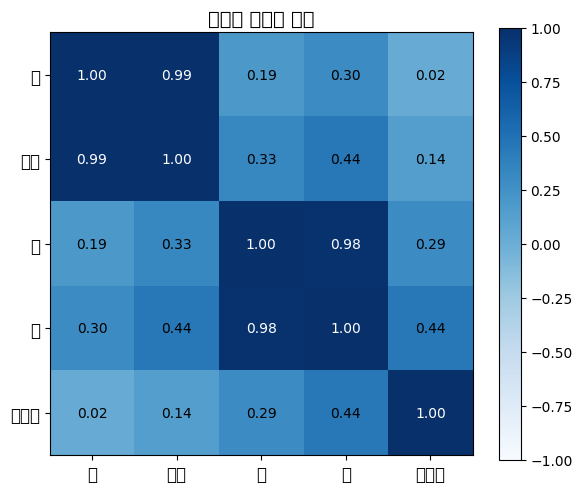

히트맵 wandb 업로드 완료 ✓


In [14]:
# ── 유사도 히트맵 시각화 + wandb에 이미지 업로드 ──────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim, cmap='Blues', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, fontsize=12)
ax.set_yticklabels(words, fontsize=12)
ax.set_title("코사인 유사도 행렬", fontsize=14)

# 각 셀에 값 표시
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{sim[i,j]:.2f}",
                ha='center', va='center',
                color='white' if sim[i,j] > 0.6 else 'black',
                fontsize=10)

plt.tight_layout()

# wandb에 이미지로 업로드
wandb.log({"cosine_similarity/heatmap": wandb.Image(fig)})
plt.savefig("cosine_similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("히트맵 wandb 업로드 완료 ✓")

---
## 4. 종합 요약 로그 — wandb에 최종 기록

In [15]:
# ── 최대 속도 향상 계산 ────────────────────────────────────────────────────
valid_speedups = [s for s in results["speedup"] if s is not None]
max_speedup = max(valid_speedups)
max_speedup_size = results["size"][results["speedup"].index(max_speedup)]

print("=" * 50)
print("과제 1 요약")
print("=" * 50)
print(f"NumPy @  vs  for loop 최대 속도 차이: {max_speedup:.0f}x  (n={max_speedup_size})")
print(f"신경망 한 층 y=xW+b: x{x.shape} @ W{W.shape} + b{b.shape} → y{y.shape}")
print(f"코사인 유사도 행렬: {len(words)}×{len(words)} 전체 쌍 한 번에 계산 완료")

# wandb에 최종 요약 지표 기록
wandb.summary.update({
    "result/max_speedup_x":       max_speedup,
    "result/max_speedup_size":     max_speedup_size,
    "result/matmul_methods_impl":  3,
    "result/broadcasting_cases":   4,
    "result/cosine_sim_complete":  True,
})

# 실험 종료
wandb.finish()
print("\nwandb run 완료 ✓")
print("wandb 대시보드에서 결과를 확인하세요!")

과제 1 요약
NumPy @  vs  for loop 최대 속도 차이: 2347x  (n=32)
신경망 한 층 y=xW+b: x(32, 128) @ W(128, 64) + b(64,) → y(32, 64)
코사인 유사도 행렬: 5×5 전체 쌍 한 번에 계산 완료


matmul/loop_ms,▁▂█
matmul/matrix_size,▁▁▂▄█
matmul/numpy_ms,▁▁▃▂█
matmul/speedup_x,▁█▁
broadcasting/case1_row_expand,True
broadcasting/case2_col_expand,True
broadcasting/case3_bias_add,True
broadcasting/case4_attn_mask,True
matmul/loop_ms,339.17644
matmul/matrix_size,256
matmul/numpy_ms,3.09587



wandb run 완료 ✓
wandb 대시보드에서 결과를 확인하세요!


---
## 5. 체크리스트 & 다음 단계

### 완료 확인
- [ ] for loop → numpy @ → einsum 세 방법 구현 및 결과 일치 확인
- [ ] 속도 비교 실험 wandb에 기록
- [ ] 브로드캐스팅 4가지 케이스 직접 검증
- [ ] 코사인 유사도 수식 → 행렬 연산으로 구현
- [ ] wandb 히트맵 이미지 업로드
- [ ] GitHub commit (`git commit -m "phase0: add linear algebra basics notebook"`)

### GitHub commit 메시지 템플릿
```
phase0/01: implement matrix multiplication & broadcasting

- matmul: for loop / numpy @ / einsum 3 methods
- broadcasting: 4 cases verified (row/col expand, bias add, attn mask)
- cosine similarity: scalar → matrix implementation
- wandb: speed comparison logged, heatmap uploaded
```

### 이 노트북에서 배운 것이 나중에 어디에 쓰이나
| 오늘 배운 것 | Phase 2에서 만나는 곳 |
|---|---|
| `A @ B` | Transformer의 모든 선형 변환, `Q @ K.T` |
| `einsum('bhqd,bhkd->bhqk')` | Multi-head Attention score 계산 |
| `(2,3) + (3,)` 브로드캐스팅 | Dense 레이어 편향 더하기 |
| `(B,H,T,T) + (T,T)` 브로드캐스팅 | Causal attention mask |
| 코사인 유사도 행렬 | 단어 임베딩 유사도, Retrieval |

### 다음 과제
Week 1 마지막: **구현 과제 2 — micrograd (자동미분 엔진 직접 구현)**